In [317]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style

import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
# neural_network
from sklearn.neural_network import MLPClassifier,\
                                   MLPRegressor,\
                                   BernoulliRBM

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
#activations
from tensorflow.keras.activations import sigmoid
#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.callbacks import TerminateOnNaN
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau



import sys
from copy import deepcopy

import kagglehub
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams



In [318]:
path = os.path.join(os.getcwd(), 'mnist_784.csv')
df = pd.read_csv(path)
print(f"total Pixal Len: {len(df.columns.values)}")
print(df.shape[0], 'Total Pixal 28x28')
X = df.drop('class',axis=1)
y = df['class']

total Pixal Len: 785
70000 Total Pixal 28x28


In [319]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"x train shape: {X_train.shape},y train shape: {y_train.shape}")

x train shape: (56000, 784),y train shape: (56000,)


##### one-hot encoded NumPy matrix:

In [320]:
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test, num_classes=10)

In [321]:
# 3. Build model using Functional API
inputs = Input(shape=(28, 28, 1))          # Input layer
print(f'{inputs.shape}')
print(f'Heres the dtype: {inputs.dtype}')

(None, 28, 28, 1)
Heres the dtype: float32


In [322]:
# Flatten image to vector
inputs = Flatten()(inputs)                      
print(f'{InData.shape}')
print(f'Heres the dtype: {InData.dtype}')

(None, 784)
Heres the dtype: float32


In [323]:
# Hidden layers
D1 = Dense(512, activation="relu",kernel_initializer = 'glorot_uniform', name="dense_1")(inputs)
D1 = Dropout(0.2)(D1)
D2 = Dense(256, activation="relu",kernel_initializer = 'glorot_uniform', name="dense_2")(D1)
D2 = Dropout(0.2)(D2)

# Output layer (10 classes)
outputs = Dense(10, activation="softmax", name="output_layer")(D2)


In [324]:
# Define model
model = Model(inputs=inputs, outputs=outputs, name="mnist_digit_model")
model.summary()

Model: "mnist_digit_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_79CLONE            │ (None, 784)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [325]:
# Compile
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [326]:
training_samples = X_train.shape[0]
batch_size_ = 128
print(f' Keras will process {int(training_samples/batch_size_)+1} batches per epoch')
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=batch_size_,
    #callbacks = callbacks = [checkpoint_cb_Epoch,early_stop_cb_val_loss],
    validation_data = (X_test, y_test),
    verbose=1
)


 Keras will process 438 batches per epoch
Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7745 - loss: 10.7630 - val_accuracy: 0.9111 - val_loss: 0.3422
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8882 - loss: 0.5414 - val_accuracy: 0.9395 - val_loss: 0.2162
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9169 - loss: 0.3226 - val_accuracy: 0.9510 - val_loss: 0.1831
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9356 - loss: 0.2286 - val_accuracy: 0.9562 - val_loss: 0.1622
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9456 - loss: 0.1990 - val_accuracy: 0.9557 - val_loss: 0.1612
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9485 - loss: 0.1763 - val_accuracy: 0.9638 - val_loss: 0.1407
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9565 - loss: 0.1552 - val_accuracy: 0.9656 - val_loss: 0.1329
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step -

In [327]:
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')

History Columns name: Index(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'epoch'], dtype='object')


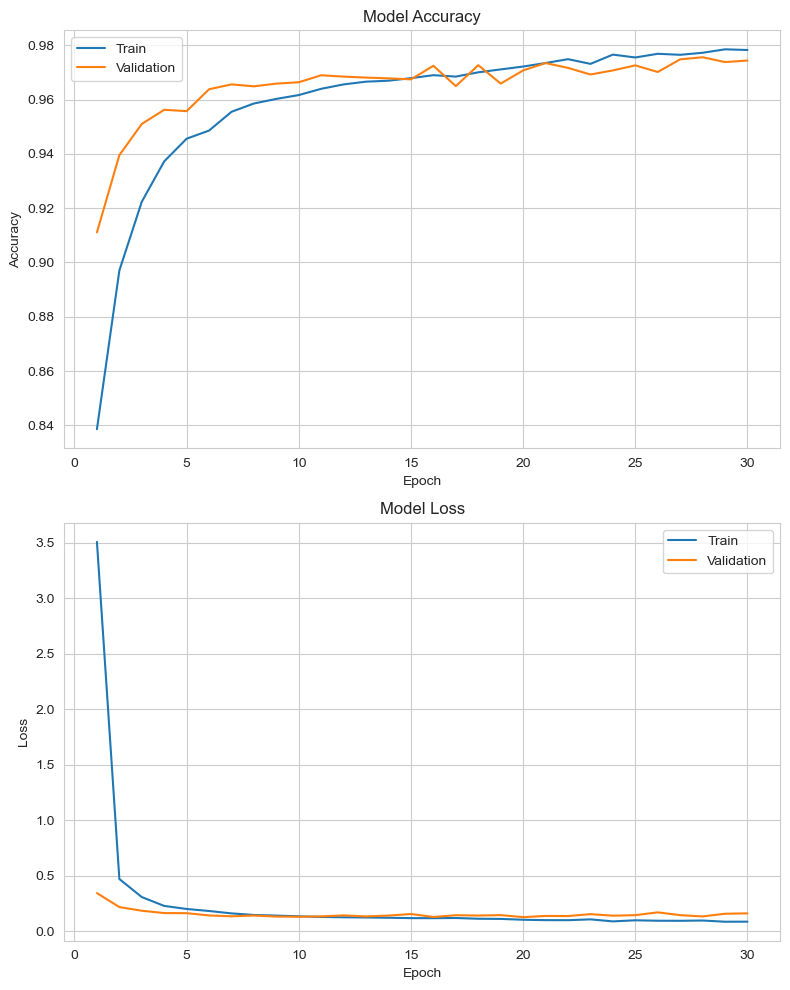

In [328]:
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y="accuracy", data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y="val_accuracy", data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y="loss", data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y="val_loss", data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [329]:
early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    mode="auto",
    verbose=1
)
training_samples = X_train.shape[0]
batch_size_ = 128
print(f' Keras will process {int(training_samples/batch_size_)+1} batches per epoch')

history_cb = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=batch_size_,
    callbacks = [early_stop_cb],
    validation_data = (X_test, y_test),
    verbose=1
)


 Keras will process 438 batches per epoch
Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9804 - loss: 0.0813 - val_accuracy: 0.9757 - val_loss: 0.1631
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9795 - loss: 0.0806 - val_accuracy: 0.9761 - val_loss: 0.1892
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9802 - loss: 0.0846 - val_accuracy: 0.9764 - val_loss: 0.1699
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9817 - loss: 0.0828 - val_accuracy: 0.9725 - val_loss: 0.1912
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9798 - loss: 0.0853 - val_accuracy: 0.9746 - val_loss: 0.1979
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9819 - loss: 0.0747 - val_accuracy: 0.9750 - val_loss: 0.1899
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [330]:
history_df = pd.DataFrame(history_cb.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')

History Columns name: Index(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'epoch'], dtype='object')


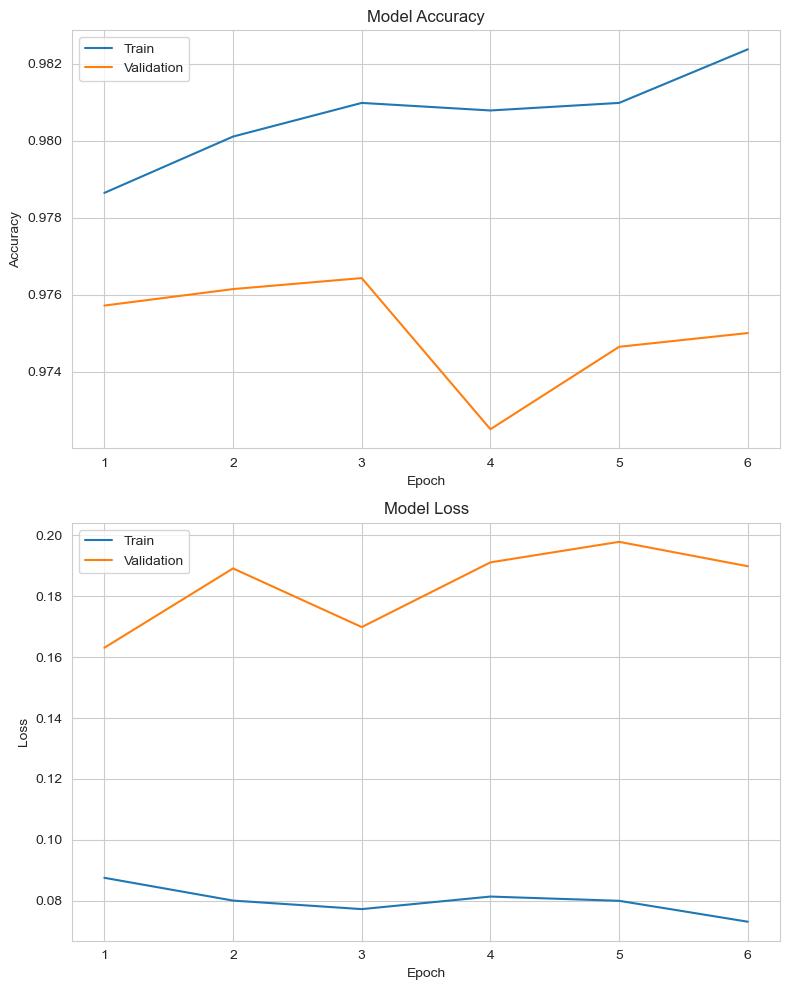

In [331]:
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y="accuracy", data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y="val_accuracy", data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y="loss", data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y="val_loss", data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [332]:
early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    mode="auto",
    verbose=1
)
training_samples = X_train.shape[0]
batch_size_ = 32
print(f' Keras will process {int(training_samples/batch_size_)+1} batches per epoch')
history_cb = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=batch_size_,
    callbacks = [early_stop_cb],
    validation_data = (X_test, y_test),
    verbose=1
)


 Keras will process 1751 batches per epoch
Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9252 - loss: 0.4160 - val_accuracy: 0.9532 - val_loss: 0.2458
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9553 - loss: 0.1956 - val_accuracy: 0.9629 - val_loss: 0.2050
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9554 - loss: 0.1929 - val_accuracy: 0.9644 - val_loss: 0.1905
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9537 - loss: 0.1994 - val_accuracy: 0.9615 - val_loss: 0.2970
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9534 - loss: 0.2208 - val_accuracy: 0.9584 - val_loss: 0.2750
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9568 - loss: 0.2004 - val_accuracy: 0.9572 - val_loss: 0.2733
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


History Columns name: Index(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'epoch'], dtype='object')


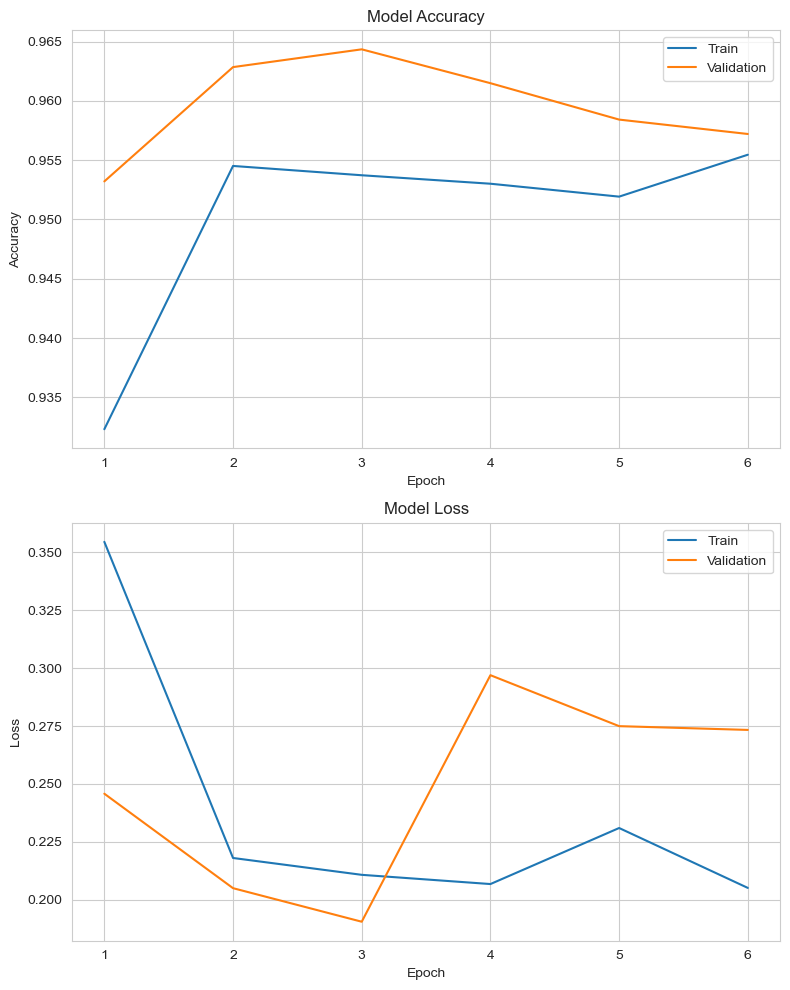

In [333]:
history_df = pd.DataFrame(history_cb.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y="accuracy", data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y="val_accuracy", data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y="loss", data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y="val_loss", data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()
